**Week 11 Assignment**


*  DSC540-T301 Data Preparation (2265-1)
*  Weeks 11 Coding Assignment
*  Nashrin Nisha Muthumohamed

**Assignments**

# 1. The Data Wrangling Workshop: Activity 8.01, page 423

The goal of this activity is to fetch data and retrieve information from two tables, persons and pets, which are a part of the petsdb database.
			Note
			You can find the petsdb database at https://packt.live/3dcH0rx.
			The persons table is defined as follows:
			
The persons table has the following columns:
			
				first_name: The first name of the person
				last_name: The last name of the person (can be null)
				age: The age of the person
				city: The city where they are from
				zip_code: The zip code of the city
			
			As we can see, the id column in the persons table (which is an integer) serves as the primary key for that table and as a foreign key for the pets table, which is linked via the owner_id column.
			The pets table is defined as follows:
            The pets table has the following columns:
			
				pet_name: The name of the pet.
				pet_type: What type of pet it is, for example, cat or dog. Due to a lack of further information, we do not know which number represents what, but it is an integer and can be null.
				treatment_done: This is also an integer column, and 0 here represents No, whereas 1 represents Yes.
			
			In this activity, you will first connect to the petsdb database and check whether the connection has been successful. You will then create and execute a few SQL commands to answer the following questions:
			
				What is the count of people belonging to different age groups in the persons table?
				Which age group has the maximum number of people?
				How many people do not have a last name?
				How many people have more than one pet?
				How many pets have received treatment?
                How many pets have received treatment, and the type of pet is known?
				How many pets are from the city called east port?
				How many pets are from the city called east port, and who received treatment?
			
			The output should be as follows:

In [2]:
# Activity 8.01: Retrieving Data from petsdb Database

import sqlite3
import requests
import os
import pandas as pd


# Step 1: Download the database correctly
db_url = "https://github.com/PacktWorkshops/The-Data-Wrangling-Workshop/raw/master/Chapter08/Activity%208.01/petsdb"
db_file = "petsdb"

# Remove old invalid file if it exists
if os.path.exists(db_file):
    os.remove(db_file)
    print("Old invalid petsdb file removed.")

print("Downloading petsdb database...")
response = requests.get(db_url)

with open(db_file, "wb") as file:
    file.write(response.content)

print("Download complete.")


# Step 2: Check whether file is a real SQLite database
with open(db_file, "rb") as file:
    header = file.read(16)

if header != b"SQLite format 3\x00":
    raise Exception("Downloaded file is not a valid SQLite database.")

print("Valid SQLite database confirmed.")


# Step 3: Connect to database
conn = sqlite3.connect(db_file)
cursor = conn.cursor()
print("Database connection successful.")


# Step 4: Check available tables
print("\nTables:")
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
print(tables)


# Step 5: Count of people by age group
print("\n1. Count of people belonging to different age groups:")

query1 = """
SELECT age, COUNT(*) AS people_count
FROM persons
GROUP BY age
ORDER BY age;
"""

print(pd.read_sql_query(query1, conn))


# Step 6: Age group with maximum number of people
print("\n2. Age group with maximum number of people:")

query2 = """
SELECT age, COUNT(*) AS people_count
FROM persons
GROUP BY age
ORDER BY people_count DESC
LIMIT 1;
"""

print(pd.read_sql_query(query2, conn))


# Step 7: People without last name
print("\n3. Number of people without last name:")

query3 = """
SELECT COUNT(*) AS people_without_last_name
FROM persons
WHERE last_name IS NULL;
"""

print(pd.read_sql_query(query3, conn))


# Step 8: People with more than one pet
print("\n4. Number of people with more than one pet:")

query4 = """
SELECT COUNT(*) AS people_with_more_than_one_pet
FROM (
    SELECT owner_id
    FROM pets
    GROUP BY owner_id
    HAVING COUNT(owner_id) > 1
);
"""

print(pd.read_sql_query(query4, conn))


# Step 9: Pets that received treatment
print("\n5. Number of pets that received treatment:")

query5 = """
SELECT COUNT(*) AS pets_received_treatment
FROM pets
WHERE treatment_done = 1;
"""

print(pd.read_sql_query(query5, conn))


# Step 10: Pets that received treatment and pet type is known
print("\n6. Number of treated pets with known pet type:")

query6 = """
SELECT COUNT(*) AS treated_pets_known_type
FROM pets
WHERE treatment_done = 1
AND pet_type IS NOT NULL;
"""

print(pd.read_sql_query(query6, conn))


# Step 11: Pets from east port
print("\n7. Number of pets from east port:")

query7 = """
SELECT COUNT(*) AS pets_from_east_port
FROM pets
JOIN persons
ON pets.owner_id = persons.id
WHERE persons.city = 'east port';
"""

print(pd.read_sql_query(query7, conn))


# Step 12: Pets from east port that received treatment
print("\n8. Number of pets from east port that received treatment:")

query8 = """
SELECT COUNT(*) AS treated_pets_from_east_port
FROM pets
JOIN persons
ON pets.owner_id = persons.id
WHERE persons.city = 'east port'
AND pets.treatment_done = 1;
"""

print(pd.read_sql_query(query8, conn))


# Step 13: Close connection
conn.close()
print("\nDatabase connection closed.")

Old invalid petsdb file removed.
Download complete.
Valid SQLite database confirmed.
Database connection successful.

Tables:
      name
0  persons
1     pets

1. Count of people belonging to different age groups:
    age  people_count
0     5             2
1     6             1
2     7             1
3     8             3
4     9             1
5    11             2
6    12             3
7    13             1
8    14             4
9    16             2
10   17             2
11   18             3
12   19             1
13   22             3
14   23             2
15   24             3
16   25             2
17   27             1
18   30             1
19   31             3
20   32             1
21   33             1
22   34             2
23   35             3
24   36             3
25   37             1
26   39             2
27   40             1
28   42             1
29   44             2
30   48             2
31   49             1
32   50             1
33   51             2
34   52         


				Write a utility function called search_movie to search for a movie by its name, print the downloaded JSON data, and save the movie poster in the local folder. Use a try-except loop for this. Use the previously created serviceurl and apikey variables. You have to pass on a dictionary with a key, t, and the movie name as the corresponding value to the urllib.parse.urlencode() function and then add the serviceurl and apikey variables to the output of the function to construct the full URL. This URL will be used to access the data. The JSON data has a key called Response. If it is True, that means the read was successful. Check this before processing the data. If it's not successful, then print the JSON key Error, which will contain the appropriate error message returned by the movie database.
				Test the search_movie function by entering Titanic. The output should look like this:http://www.omdbapi.com/?t=Titanic&apikey=<your API key>
				

In [15]:
# Activity 7.02: Building Your Own Movie Database by Reading an API

# Step 1: Import required libraries
import urllib.request
import urllib.parse
import urllib.error
import json
import os


# Step 2: Load OMDb API key from APIkeys.json
# The JSON file should be in the same folder as this Python file.
# Example APIkeys.json:
# {
#     "OMDBapi": "your_api_key_here"
# }

with open("APIkeys.json", "r") as file:
    keys = json.loads(file.read())

secretapikey = keys["OMDBapi"]


# Step 3: Store the OMDb API URL
serviceurl = "http://www.omdbapi.com/?"


# Step 4: Create API key portion of URL
apikey = "&apikey=" + secretapikey


# Step 5: Utility function to print JSON data nicely
def print_json(json_data):
    """Print movie data from JSON response."""
    print("\nMovie Information:")
    print("-" * 50)

    for key, value in json_data.items():
        print(f"{key}: {value}")


# Step 6: Utility function to download movie poster
def download_poster(json_data, save_folder="."):
    """Download movie poster and save it locally."""

    poster_url = json_data.get("Poster")

    if poster_url == "N/A" or poster_url is None:
        print("\nNo poster available for this movie.")
        return

    movie_title = json_data.get("Title", "movie")
    poster_file_name = movie_title.replace(" ", "_") + "_poster.jpg"

    if not os.path.exists(save_folder):
        os.makedirs(save_folder)

    file_path = os.path.join(save_folder, poster_file_name)

    try:
        print("\nDownloading poster...")
        poster_data = urllib.request.urlopen(poster_url).read()

        poster_file = open(file_path, "wb")
        poster_file.write(poster_data)
        poster_file.close()

        print("Poster saved at:", file_path)

    except Exception as error:
        print("Could not download poster.")
        print("Error:", error)


# Step 7: Utility function to search movie
def search_movie(movie_name, save_folder="."):
    """Search movie by name, print JSON data, and download poster."""

    try:
        # Create dictionary with movie title
        movie_dict = {"t": movie_name}

        # Encode movie name for URL
        encoded_movie_name = urllib.parse.urlencode(movie_dict)

        # Create full API URL
        full_url = serviceurl + encoded_movie_name + apikey

        print("\nAccessing URL:")
        print(full_url)

        # Read data from OMDb API
        response = urllib.request.urlopen(full_url)
        data = response.read().decode()

        # Convert JSON string to Python dictionary
        json_data = json.loads(data)

        # Check if API response is successful
        if json_data["Response"] == "True":
            print_json(json_data)
            download_poster(json_data, save_folder)
        else:
            print("\nMovie not found.")
            print("Error:", json_data["Error"])

    except urllib.error.URLError as error:
        print("URL error occurred:", error)

    except Exception as error:
        print("An error occurred:", error)


# Step 8: Test the function with Titanic
search_movie("Titanic", save_folder="movie_posters")


Accessing URL:
http://www.omdbapi.com/?t=Titanic&apikey=8610021b

Movie Information:
--------------------------------------------------
Title: Titanic
Year: 1997
Rated: PG-13
Released: 19 Dec 1997
Runtime: 194 min
Genre: Drama, Romance
Director: James Cameron
Writer: James Cameron
Actors: Leonardo DiCaprio, Kate Winslet, Billy Zane
Plot: A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic.
Language: English, Swedish, Italian, French
Country: United States, Mexico
Awards: Won 11 Oscars. 126 wins & 84 nominations total
Poster: https://m.media-amazon.com/images/M/MV5BYzYyN2FiZmUtYWYzMy00MzViLWJkZTMtOGY1ZjgzNWMwN2YxXkEyXkFqcGc@._V1_QL75_UX380_CR0,2,380,562_.jpg
Ratings: [{'Source': 'Internet Movie Database', 'Value': '8.0/10'}, {'Source': 'Rotten Tomatoes', 'Value': '88%'}, {'Source': 'Metacritic', 'Value': '75/100'}]
Metascore: 75
imdbRating: 8.0
imdbVotes: 1,389,357
imdbID: tt0120338
Type: movie
DVD: N/A
BoxOffice: $67

# 3. Connect to an API of your choice and do a simple data pull

Connect to an API of your choice and do a simple data pull - you can use any API - except the API you have selected for your project.
In previous versions of this course we have always used Twitter, but with recent organizational changes at Twitter, it has become increasingly difficult to access the free APIs available at Twitter. You are more than welcome to try to use Twitter's API for this portion of the assignment, but please note, there has been some inconsistency experienced when following along with their documentation posted.
Connect to the API and do a "Get" call/operation on the API to return a subset of data from the API

In [16]:
# Simple API GET Call Assignment
# API Used: Open-Meteo Weather API
# Purpose: Pull a subset of weather forecast data

# Step 1: Import required libraries
import requests
import pandas as pd


# Step 2: Define the API endpoint
url = "https://api.open-meteo.com/v1/forecast"


# Step 3: Define query parameters
# Example location: New York City
params = {
    "latitude": 40.7128,
    "longitude": -74.0060,
    "current": "temperature_2m,wind_speed_10m",
    "hourly": "temperature_2m",
    "forecast_days": 1
}


# Step 4: Send GET request to the API
response = requests.get(url, params=params)


# Step 5: Check if the request was successful
if response.status_code == 200:
    print("GET request successful.")
else:
    print("GET request failed.")
    print("Status code:", response.status_code)


# Step 6: Convert JSON response into Python dictionary
data = response.json()


# Step 7: Print basic subset of current weather data
print("\nCurrent Weather Data:")
print(data["current"])


# Step 8: Create a small DataFrame from hourly forecast data
hourly_data = {
    "time": data["hourly"]["time"],
    "temperature_2m": data["hourly"]["temperature_2m"]
}

df = pd.DataFrame(hourly_data)


# Step 9: Print only first 10 rows as subset
print("\nHourly Temperature Forecast Subset:")
print(df.head(10))

GET request successful.

Current Weather Data:
{'time': '2026-05-24T19:30', 'interval': 900, 'temperature_2m': 13.3, 'wind_speed_10m': 11.7}

Hourly Temperature Forecast Subset:
               time  temperature_2m
0  2026-05-24T00:00             9.6
1  2026-05-24T01:00             9.7
2  2026-05-24T02:00            10.1
3  2026-05-24T03:00            10.3
4  2026-05-24T04:00            10.2
5  2026-05-24T05:00            10.3
6  2026-05-24T06:00            10.2
7  2026-05-24T07:00            10.5
8  2026-05-24T08:00            10.2
9  2026-05-24T09:00            10.4


# 4. Visualization

Using one of the datasets provided in Weeks 7 & 8, or a dataset of your own, choose 3 of the following visualizations to complete. You must submit via PDF along with your code if you are using PyCharm, otherwise if you submit a notebook file make sure your plots are visible in your notebook or PDF that you submit. You are free to use Matplotlib, Seaborn or another package if you prefer.


Line
Scatter
Bar
Histogram
Density Plot
Pie Chart

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


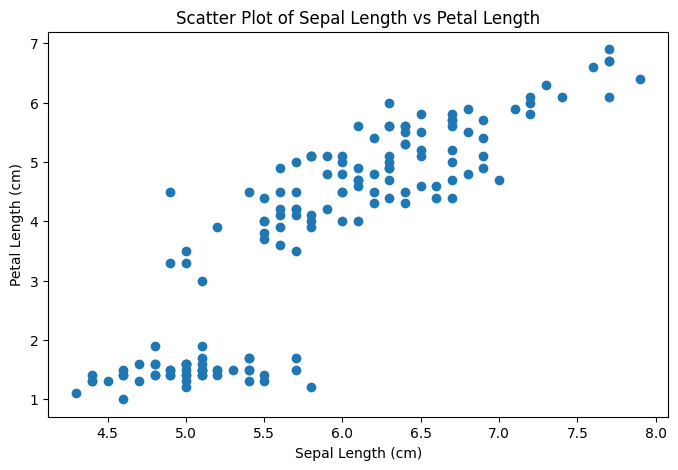

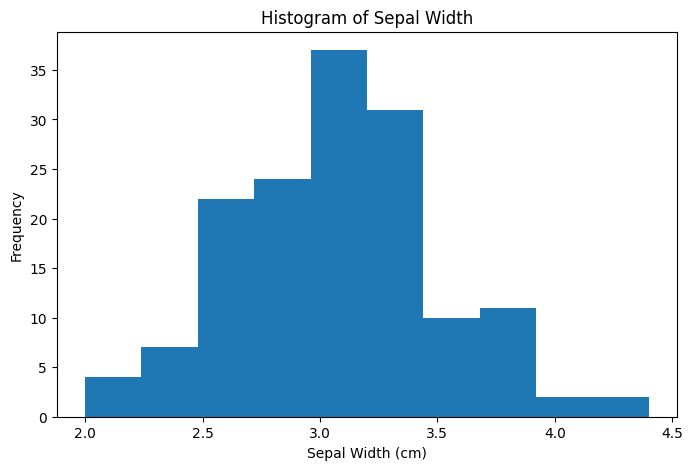

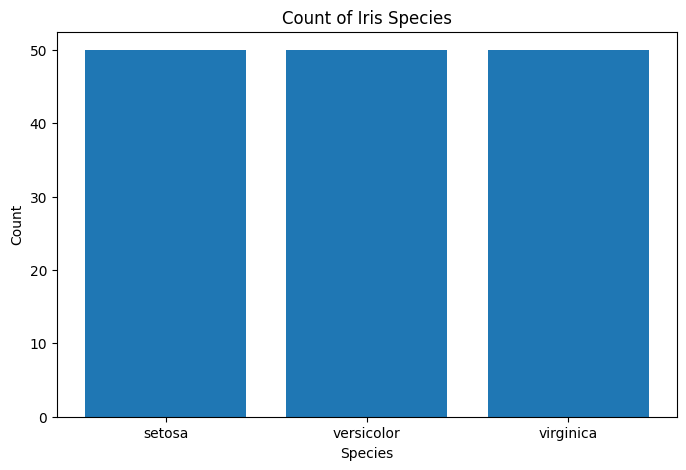

In [17]:
# Data Visualization Assignment
# Dataset Used: Built-in Iris Dataset from sklearn
# Visualizations: Scatter Plot, Histogram, Bar Chart

# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


# Step 2: Load Iris dataset without internet
iris_data = load_iris()

iris = pd.DataFrame(
    iris_data.data,
    columns=iris_data.feature_names
)

iris["species"] = iris_data.target
iris["species"] = iris["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("First 5 rows:")
print(iris.head())


# ---------------------------------------------------------
# Visualization 1: Scatter Plot
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    iris["sepal length (cm)"],
    iris["petal length (cm)"]
)

plt.title("Scatter Plot of Sepal Length vs Petal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.show()


# ---------------------------------------------------------
# Visualization 2: Histogram
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    iris["sepal width (cm)"],
    bins=10
)

plt.title("Histogram of Sepal Width")
plt.xlabel("Sepal Width (cm)")
plt.ylabel("Frequency")
plt.show()


# ---------------------------------------------------------
# Visualization 3: Bar Chart
# ---------------------------------------------------------
species_count = iris["species"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    species_count.index,
    species_count.values
)

plt.title("Count of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()